## Load Required Library and Necessary Types

In [ ]:
import os
import time
import lzma
import glob
import numpy as np
from typing import *
from pathlib import Path
try:
  from pysat.formula import WCNF
except:
  !pip install python-sat
  from pysat.formula import WCNF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.5 MB/s eta 0:00:00


## Prepare Dataset from SAT Benchmark
* Download the dataset from **MaxSAT Evaluation Benchmarks** : https://maxsat-evaluations.github.io/{_year_}/benchmarks.html

* Note that we can only download the dataset from **MaxSAT Evaluation Benchmarks** from 2024 to 2017.
* The links of 8 years of MaxSAT Benchmark datasets from 2024 (included) to 2017 (included) are :
  - https://maxsat-evaluations.github.io/2024/benchmarks.html
  - https://maxsat-evaluations.github.io/2023/benchmarks.html
  - https://maxsat-evaluations.github.io/2022/benchmarks.html
  - https://maxsat-evaluations.github.io/2021/benchmarks.html
  - https://maxsat-evaluations.github.io/2020/benchmarks.html
  - https://maxsat-evaluations.github.io/2019/benchmarks.html
  - https://maxsat-evaluations.github.io/2018/benchmarks.html
  - https://maxsat-evaluations.github.io/2017/benchmarks.html

* And the download URL are :
  - 2024 : https://www.cs.helsinki.fi/group/coreo/MSE2024-instances/mse24-exact-unweighted.zip
  - 2023 : https://drive.google.com/file/d/13qDbScs9jU1VaUaq4L7qSGEUrHxC9t6d/view?usp=drive_link
  - 2022 : https://drive.google.com/file/d/1j2UcXFId7EDbgaiuaYeUnBqJjlAXo1aK/view?usp=sharing
  - 2021 : https://www.cs.helsinki.fi/group/coreo/mse2021/mse2021_benchmarks/mse21_complete_wt.zip
  - 2020 : http://www.cs.toronto.edu/maxsat-lib/maxsat-instances/downloads/ms-evals/ms20_complete_wt.zip
  - 2019 : http://www.cs.toronto.edu/maxsat-lib/maxsat-instances/downloads/ms-evals/ms19_complete_unwt.zip
  - 2018 : http://www.cs.toronto.edu/maxsat-lib/maxsat-instances/downloads/ms-evals/ms18_complete_unwt.zip
  - 2017 : https://drive.google.com/file/d/0BzmN8SXo_mHrYzJKWFBhM1NrX28/view?usp=sharing&resourcekey=0-41xIORjRpFa_VcA4mxCPkQ

In [ ]:
class DatasetPreparer():
  def __init__(
      self,
      zips_path: str = "/content/dataset-zips/",
      outputs_path: str = "/content/dataset-outputs/",
      reader_mode: str = "rt",
      reader_encoding: str = 'utf-8',
      reader_error_mode: str = "ignore",
    ) -> None:
    # variables for downloading dataset from MaxSAT Evaluation Benchmarks
    self.zips_path: str = zips_path
    self.outputs_path: str = outputs_path
    Path(self.zips_path).mkdir(parents=True, exist_ok=True)
    Path(self.outputs_path).mkdir(parents=True, exist_ok=True)

    self.maxsat_benchmark_dowload_urls: Dict[int, str] = {
      2024: "https://www.cs.helsinki.fi/group/coreo/MSE2024-instances/mse24-exact-unweighted.zip",
      2023: "https://drive.google.com/file/d/13qDbScs9jU1VaUaq4L7qSGEUrHxC9t6d/view?usp=drive_link",
      2022: "https://drive.google.com/file/d/1j2UcXFId7EDbgaiuaYeUnBqJjlAXo1aK/view?usp=sharing",
      2021: "https://www.cs.helsinki.fi/group/coreo/mse2021/mse2021_benchmarks/mse21_complete_wt.zip",
      2020: "http://www.cs.toronto.edu/maxsat-lib/maxsat-instances/downloads/ms-evals/ms20_complete_wt.zip",
      2019: "http://www.cs.toronto.edu/maxsat-lib/maxsat-instances/downloads/ms-evals/ms19_complete_unwt.zip",
      2018: "http://www.cs.toronto.edu/maxsat-lib/maxsat-instances/downloads/ms-evals/ms18_complete_unwt.zip",
      2017: "https://drive.google.com/file/d/0BzmN8SXo_mHrYzJKWFBhM1NrX28/view?usp=sharing&resourcekey=0-41xIORjRpFa_VcA4mxCPkQ",
    }

    # variables for WCNF reader
    self.reader_mode = reader_mode
    self.reader_encoding = reader_encoding
    self.reader_error_mode = reader_error_modet
    self.content_comment_sign = 'c'
    self.content_ignore_sign = 'p'
    self.content_hard_sign = 'h'
    self.content_end_of_line_sign = '0'

  def download_and_unzip_datasets_by_years(self, years: List[int]) -> List[str]:
    dataset_paths: List[str] = []
    for year in years:
      download_url: str = self.maxsat_benchmark_dowload_urls[year]
      dataset_name: str = f"maxsat_dataset_{year}"
      zip_path = f"{self.zips_path}{dataset_name}.zip"
      extract_path = f"{self.outputs_path}{dataset_name}"
      dataset_paths.append(extract_path)
      print(f"⬇️ Downloading {dataset_name}...")
      os.system(f'wget -O "{zip_path}" "{download_url}"')

      print(f"🧩 Extracting {dataset_name} to {extract_path} ...")
      Path(extract_path).mkdir(parents=True, exist_ok=True)
      os.system(f'unzip -o -q "{zip_path}" -d "{extract_path}"')
    return dataset_paths

  def get_wcnf_files_from_dataset_path(self, dataset_path: str) -> List[str]:
      """ read all .wcnf.xz files from the dataset_path"""
      return glob.glob(f"{dataset_path}/*.wcnf.xz", recursive=True)

  def read_wcnfxz_file_to_clauses(self, filepath: str) -> Tuple[List[List[int]], List[List[int]]]:
      soft_clauses = []
      hard_clauses = []
      with lzma.open(filepath, mode=self.reader_mode, encoding=self.reader_encoding, errors=self.reader_error_mode) as file:
          for line in file:
              line = line.strip()
              if not line or line.startswith(self.content_comment_sign) or line.startswith(self.content_ignore_sign):
                  continue
              parts = line.split()
              if parts[-1] != self.content_end_of_line_sign:  # note that 0 indicate the end of line
                  continue
              # start with n (n for some integer) means the weighted of that clause,
              #                 h means the current line(clause) is the hard clause,
              #                 c means the current line is a comment
              try:
                  if parts[0] == self.content_hard_sign:
                      clause = list(map(int, parts[1:-1]))
                      hard_clauses.append(clause)
                  else:
                      weight = int(parts[0])
                      clause = list(map(int, parts[1:-1]))
                      if weight == 1:
                          soft_clauses.append(clause)
                      else:
                          hard_clauses.append(clause)
              except ValueError:
                  continue

      return soft_clauses, hard_clauses

  def convert_to_wcnf(self, clauses: List[List[int]]) -> WCNF:
      wcnf = WCNF()
      for clause in clauses:
        wcnf.append(clause)
      return wcnf

### Using dataset preparer to get the dataset

In [ ]:
# setup the preparer
preparer = DatasetPreparer()

# download and unzip the dataset using the dataset preparer
dataset_paths = preparer.download_and_unzip_datasets_by_years(years=[2024])
print(dataset_paths)

# get the WCNF paths and extract the clauses
tiny_soft_clauses, tiny_hard_clauses = [], [] # since the original dataset is too large, we use a tiny(trimmed) one here
tiny_soft_clauses_formula, tiny_hard_clauses_formula = None, None
current_number_of_clauses = 10e9
max_try_count = 10
for dataset_path in dataset_paths:
  wcnf_paths = preparer.get_wcnf_files_from_dataset_path(dataset_path)
  for wcnf_path in wcnf_paths:
    if max_try_count < 0:
      break;
    max_try_count -= 1
    soft_clauses, hard_clauses = preparer.read_wcnfxz_file_to_clauses(wcnf_path)
    soft_clauses_formula, hard_clauses_formula = preparer.convert_to_wcnf(soft_clauses), preparer.convert_to_wcnf(hard_clauses)
    if soft_clauses_formula.nv < current_number_of_clauses:
      tiny_soft_clauses = soft_clauses
      tiny_hard_clauses = hard_clauses
      tiny_soft_clauses_formula = soft_clauses_formula
      tiny_hard_clauses_formula = hard_clauses_formula
      current_number_of_clauses = soft_clauses_formula.nv

NameError: name 'reader_error_modet' is not defined

In [ ]:
print(tiny_soft_clauses)
print(tiny_soft_clauses_formula)

NameError: name 'tiny_soft_clauses' is not defined

### Prepare Dataset of Hard Problem in PySAT
Documentations URL : https://pysathq.github.io/docs/html/api/examples/genhard.html

In [ ]:
def get_max_variable_number(instance: WCNF) -> int:
  max_var = instance.nv
  for clause in instance.soft:
      for literal in clause:
          max_var = max(max_var, abs(literal))
  return max_var

In [ ]:
try:
  from pysat.examples.genhard import CB
  from pysat.examples.genhard import GT
  from pysat.examples.genhard import PAR
  from pysat.examples.genhard import PHP
except:
  !pip install python-sat
  from pysat.examples.genhard import CB
  from pysat.examples.genhard import GT
  from pysat.examples.genhard import PAR
  from pysat.examples.genhard import PHP

cnfs = [
    CB(5),
    CB(10),

    GT(10),
    GT(20),

    PAR(10),
    PAR(15),

    PHP(10),
    PHP(20),
]

instances = [WCNF() for _ in range(len(cnfs))]
for index in range(len(cnfs)):
  for clause in cnfs[index].clauses:
      instances[index].append(clause, weight=1)
  print(f"Variables: {instances[index].nv}")
  print(f"Soft clauses: {instances[index].soft}")
  print(f"Hard clauses: {instances[index].hard}")
  print(f"Maximum variable number: {get_max_variable_number(instances[index])}")
  print(str(instances[index]))
  print("=" * 60)

Variables: 176
Soft clauses: [[1, 2], [-2, -3], [-2, -4], [-3, -4], [4, 5, 6], [-6, -7], [-6, -8], [-7, -8], [8, 9, 10], [-10, -11], [-10, -12], [-11, -12], [12, 13, 14], [-14, -15], [-14, -16], [-15, -16], [16, 17], [18, 19], [-1, -19], [-1, -20], [-1, -21], [-19, -20], [-19, -21], [-20, -21], [3, 21, 22, 23], [-5, -23], [-5, -24], [-5, -25], [-23, -24], [-23, -25], [-24, -25], [7, 25, 26, 27], [-9, -27], [-9, -28], [-9, -29], [-27, -28], [-27, -29], [-28, -29], [11, 29, 30, 31], [-13, -31], [-13, -32], [-13, -33], [-31, -32], [-31, -33], [-32, -33], [15, 33, 34, 35], [-17, -35], [-17, -36], [-35, -36], [-18, -37], [-18, -38], [-37, -38], [20, 38, 39, 40], [-22, -40], [-22, -41], [-22, -42], [-40, -41], [-40, -42], [-41, -42], [24, 42, 43, 44], [-26, -44], [-26, -45], [-26, -46], [-44, -45], [-44, -46], [-45, -46], [28, 46, 47, 48], [-30, -48], [-30, -49], [-30, -50], [-48, -49], [-48, -50], [-49, -50], [32, 50, 51, 52], [-34, -52], [-34, -53], [-34, -54], [-52, -53], [-52, -54], [-53

## LSU algorithm

In [ ]:
import json

try:
  import threading
  from pysat.examples.lsu import LSU
except Exception as error:
  !pip install python-sat
  import threading
  from pysat.examples.lsu import LSU

for instance in instances:
  start_time = time.time()

  lsu = LSU(instance, verbose=1)
  is_sat = lsu.solve()

  end_time = time.time()

  print("=" * 60)
  print("Result of LSU MaxSAT Solver")
  print("=" * 60)

  if is_sat:
    print(f"is SAT")
    print(f"Optimal Solution Found: {'Yes' if lsu.found_optimum() else 'No'}")
    print(f"Minimum Cost: {getattr(lsu, 'cost', 'N/A')}")
    print(f"Execution Time: {(end_time - start_time):.4f} sec")

    raw_model = lsu.get_model()
    model = list(raw_model) if raw_model else None

    if model:
      print(f"\nModel length: {len(model)}")
      print(f"Number of Variables: {max(abs(lit) for lit in model) if model else 0}")

      max_var = max(max(abs(lit) for lit in clause) for clause in instance.soft) if instance.soft else 0
      filtered_model = [lit for lit in model if abs(lit) <= max_var]

      if filtered_model:
          positive_vars = [lit for lit in filtered_model if lit > 0]
          negative_vars = [abs(lit) for lit in filtered_model if lit < 0]

          print(f"\nBest Assignment:")
          print(f"   True Assignments (count: {len(positive_vars)}): {sorted(positive_vars)[:20]}{'...' if len(positive_vars) > 20 else ''}")
          print(f"   False Assignments (count: {len(negative_vars)}): {sorted(negative_vars)[:20]}{'...' if len(negative_vars) > 20 else ''}")

          model_set = set(filtered_model)
          satisfied_count = 0
          unsatisfied_clauses = []

          for i, clause in enumerate(instance.soft):
              is_satisfied = any(lit in model_set for lit in clause)
              if is_satisfied:
                  satisfied_count += 1
              else:
                  unsatisfied_clauses.append(i)

          print(f"\nSatisfied Soft Clauses: {satisfied_count}/{len(instance.soft)}")
          print(f"Unsatisfied Soft Clauses: {len(unsatisfied_clauses)}/{len(instance.soft)}")

          if len(unsatisfied_clauses) <= 5:
              print(f"   unsatisfied clause variables: {unsatisfied_clauses}")

          print(f"\n All the Assignment:")
          limit = 10e9 # can set the maximum number of the variables here
          assignment_display = []
          for var in range(1, min(limit, max_var + 1)):
              if var in positive_vars:
                  assignment_display.append(f"x{var}=T")
              elif var in negative_vars:
                  assignment_display.append(f"x{var}=F")
              else:
                  assignment_display.append(f"x{var}=?")

          for i in range(0, len(assignment_display), 10):
              print(f"   {', '.join(assignment_display[i:i+10])}")

      else:
          print("\nThere's no valid assignment after filtering")
    else:
      print("\nFailed to get the model")

  else:
    print("UNSAT")
    print(f"Execution Time: {(end_time - start_time):.4f} sec")

  print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 23.5 MB/s eta 0:00:00


NameError: name 'instances' is not defined

## The original TorchmSAT

In [ ]:
import time

try:
  import torch
except:
  !pip install torch
  import torch


class TorchmSATModel(torch.nn.Module):
    def __init__(self, nv, clauses, use_gpu=False) -> None:
        super(TorchmSATModel, self).__init__()
        device = (
            torch.device("cuda") if torch.cuda.is_available() and use_gpu else torch.device("cpu")
        )

        self.e = torch.ones((1, nv), device=device, dtype=torch.half)
        x = torch.rand((1, nv), device=device, dtype=torch.half)
        self.x = torch.nn.Parameter(x)

        self.W = torch.zeros((nv, len(clauses)), dtype=torch.half)

        self.target = torch.zeros((1, len(clauses)), device=device, dtype=torch.half)

        self.SAT = torch.zeros((1, len(clauses)), dtype=torch.half)
        for clause_idx, clause in enumerate(clauses):
            for literal in clause:
                value = 1.0 if literal > 0 else -1.0
                literal_idx = abs(literal) - 1
                self.W[literal_idx, clause_idx] = value
            self.SAT[0, clause_idx] = -len(clause)

        # Auxiliary for reporting a solution
        self.sol = torch.empty_like(self.x, device=device, dtype=torch.half)

        # GPU
        self.W = self.W.to(device)
        self.SAT = self.SAT.to(device)

    def forward(self):
        act = torch.tanh(self.e * self.x) @ self.W
        self.sol[self.x > 0] = 1.0
        self.sol[self.x <= 0] = -1.0
        return act

    def sat(self):
        unsat_clauses = (self.sol @ self.W) == self.SAT
        cost = torch.sum(unsat_clauses).item()
        return cost, unsat_clauses

    def __str__(self) -> str:
        return f"W={self.W}"


class TorchmSATSolver:
    def __init__(self, nv, clauses, lr=1e-4, use_gpu=False) -> None:
        self.trace = {
            "start_time": 0.0,
            "nn_build_time": 0.0,
            "max_sat_time": 0.0,
            "total_time": 0.0,
            "cost": len(clauses),
            "nv": nv,
            "nc": len(clauses),
            "sols": {},
        }
        self.trace["start_time"] = time.time()

        self.model = TorchmSATModel(nv, clauses, use_gpu)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.loss = torch.nn.MSELoss()

        self.trace["nn_build_time"] = time.time() - self.trace["start_time"]

    def compute(self, unmasked_steps=1000, masked_steps=4000):
        solve_start_time = time.time()
        for i in range(unmasked_steps):
            self.optimizer.zero_grad()
            out = self.model()
            output = self.loss(out, self.model.target)
            output.backward()
            self.optimizer.step()

            cost, _ = self.model.sat()
            if cost < self.trace["cost"]:
                self.trace["cost"] = cost
                self.trace["max_sat_time"] = time.time() - solve_start_time
                self.trace["sols"][cost] = [(i, self.sol_str())]
            elif cost == self.trace["cost"] and self.sol_str() not in list(
                map(lambda sol: sol[1], self.trace["sols"][cost])
            ):
                # Pareto frontier solutions at the lowest cost so far (till this iteration)
                self.trace["sols"][cost].append((i, self.sol_str()))

        # Focus on the unsatisfied clauses
        for j in range(int(masked_steps / 100)):
            cost, unsat_clauses = self.model.sat()
            for k in range(100):
                self.optimizer.zero_grad()
                out = self.model()
                output = self.loss(
                    torch.masked_select(out, unsat_clauses),
                    torch.masked_select(self.model.target, unsat_clauses),
                )
                output.backward()
                self.optimizer.step()

                cost, _ = self.model.sat()
                if cost < self.trace["cost"]:
                    self.trace["cost"] = cost
                    self.trace["max_sat_time"] = time.time() - solve_start_time
                    self.trace["sols"][cost] = [(i, self.sol_str())]
                elif cost == self.trace["cost"] and self.sol_str() not in list(
                    map(lambda sol: sol[1], self.trace["sols"][cost])
                ):
                    # Pareto frontier solutions at the lowest cost so far (till this iteration)
                    self.trace["sols"][cost].append((1000 + j + k, self.sol_str()))

        # Report total search time
        self.trace["total_time"] = time.time() - solve_start_time
        return self.max_sat()

    def max_sat(self):
        return self.trace

    def sol_str(self):
        return (
            ",".join([str(1 if var > 0 else 0) for var in self.model.sol.flatten().tolist()]) + "\n"
        )

In [ ]:
s = TorchmSATSolver(tiny_soft_clauses_formula.nv, soft_clauses)
res = s.compute()
print(json.dumps(res, indent=2, ensure_ascii=False))

NameError: name 'tiny_soft_clauses_formula' is not defined

## GraphSAT


=== Dataset 0 (Variables=176, Clauses=290) ===
TorchmSAT: cost=181, sols=1, first_best=0, time=0.9495s
GraphSAT (GNN): cost=70, sols=1, first_best=0, time=4.5868s
GraphAttentionSAT (GAT): cost=42, sols=1, first_best=0, time=4.4921s

=== Dataset 1 (Variables=756, Clauses=1280) ===
TorchmSAT: cost=159, sols=1, first_best=0, time=4.3802s
GraphSAT (GNN): cost=272, sols=1, first_best=0, time=14.3005s
GraphAttentionSAT (GAT): cost=633, sols=1, first_best=0, time=15.6714s

=== Dataset 2 (Variables=90, Clauses=775) ===
TorchmSAT: cost=45, sols=1, first_best=0, time=0.7847s
GraphSAT (GNN): cost=82, sols=1, first_best=0, time=9.2218s
GraphAttentionSAT (GAT): cost=131, sols=1, first_best=0, time=9.7645s

=== Dataset 3 (Variables=380, Clauses=7050) ===
TorchmSAT: cost=180, sols=1, first_best=0, time=10.9707s
GraphSAT (GNN): cost=926, sols=1, first_best=0, time=77.3514s
GraphAttentionSAT (GAT): cost=1070, sols=1, first_best=0, time=78.2032s

=== Dataset 4 (Variables=210, Clauses=4011) ===
TorchmSA

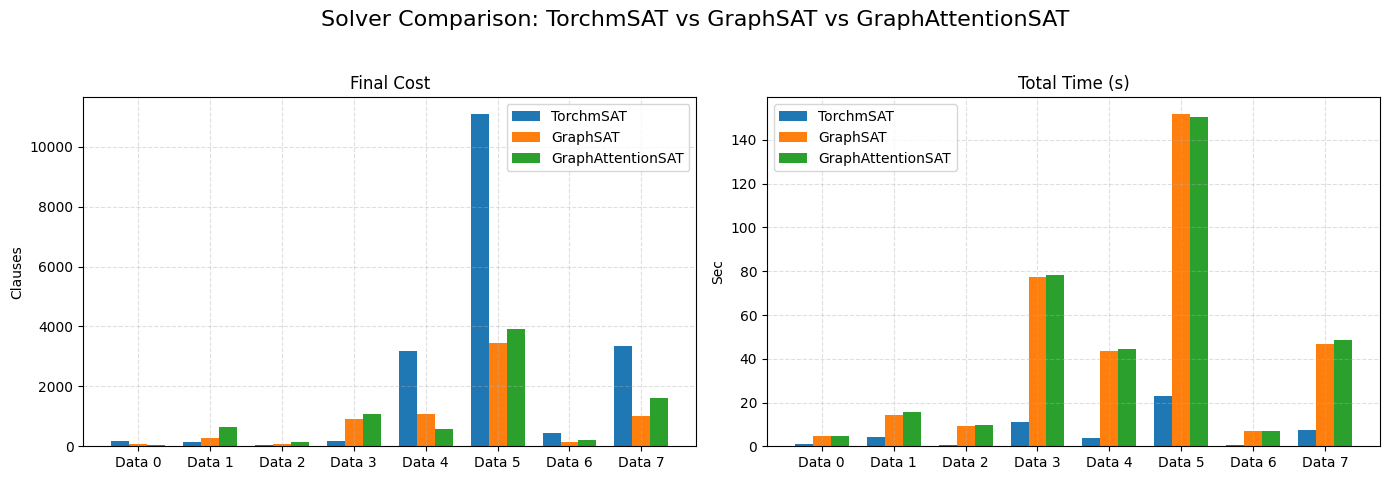

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import numpy as np
from pysat.formula import WCNF

# =====================
# 原始 TorchmSAT
# =====================
class TorchmSATModel(nn.Module):
    def __init__(self, nv, clauses, use_gpu=False):
        super().__init__()
        device = torch.device("cuda") if torch.cuda.is_available() and use_gpu else torch.device("cpu")
        self.e = torch.ones((1, nv), device=device, dtype=torch.half)
        x = torch.rand((1, nv), device=device, dtype=torch.half)
        self.x = nn.Parameter(x)
        self.W = torch.zeros((nv, len(clauses)), dtype=torch.half, device=device)
        self.SAT = torch.zeros((1, len(clauses)), dtype=torch.half, device=device)
        for j, clause in enumerate(clauses):
            for lit in clause:
                i = abs(lit)-1
                self.W[i,j] = 1.0 if lit>0 else -1.0
            self.SAT[0,j] = -len(clause)
        self.sol = torch.empty_like(self.x, device=device, dtype=torch.half)

    def forward(self):
        act = torch.tanh(self.e * self.x) @ self.W
        self.sol[self.x>0] = 1.0
        self.sol[self.x<=0] = -1.0
        return act

    def sat(self):
        unsat_clauses = (self.sol @ self.W) == self.SAT
        cost = torch.sum(unsat_clauses).item()
        return cost, unsat_clauses

class TorchmSATSolver:
    def __init__(self, nv, clauses, lr=1e-4):
        self.model = TorchmSATModel(nv, clauses)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.loss = nn.MSELoss()
        self.trace = {"cost": len(clauses), "sols": {}, "total_time": 0.0, "first_best": None}

    def compute(self, steps=1000):
        start = time.time()
        for i in range(steps):
            self.optimizer.zero_grad()
            out = self.model()
            target = torch.zeros_like(out)
            loss = self.loss(out, target)
            loss.backward()
            self.optimizer.step()
            cost, _ = self.model.sat()
            if cost < self.trace["cost"]:
                self.trace["cost"] = cost
                self.trace["sols"] = {cost: [(i, self.sol_str())]}
                if self.trace["first_best"] is None:
                    self.trace["first_best"] = i
            elif cost == self.trace["cost"]:
                s = self.sol_str()
                if s not in [x[1] for x in self.trace["sols"][cost]]:
                    self.trace["sols"][cost].append((i,s))
        self.trace["total_time"] = time.time() - start
        return self.trace

    def sol_str(self):
        return ",".join([str(1 if var>0 else 0) for var in self.model.sol.flatten().tolist()])

# =====================
# GraphSAT (GNN)
# =====================
class GraphSATModel(nn.Module):
    def __init__(self, nv, clauses, hidden_dim=64):
        super().__init__()
        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        self.device = device
        self.nv = nv
        self.nc = len(clauses)
        W = torch.zeros((nv, self.nc), device=device)
        for j, clause in enumerate(clauses):
            for lit in clause:
                i = abs(lit)-1
                W[i,j] = 1.0 if lit>0 else -1.0
        self.W = W
        self.h_v = nn.Parameter(torch.randn((nv, hidden_dim), device=device))
        self.h_c = torch.zeros((self.nc, hidden_dim), device=device)
        self.var_to_clause = nn.Linear(hidden_dim, hidden_dim, bias=False, device=device)
        self.clause_to_var = nn.Linear(hidden_dim, hidden_dim, bias=False, device=device)

    def forward(self, steps=3):
        h_v = self.h_v
        h_c = self.h_c
        for _ in range(steps):
            # messages from variable to clauses
            msg_c = torch.matmul(self.W.T, torch.tanh(self.var_to_clause(h_v))) / (self.W.T.abs().sum(dim=1, keepdim=True)+1e-6)
            h_c = torch.tanh(msg_c)
            # messages from clauses to variables
            msg_v = torch.matmul(self.W, torch.tanh(self.clause_to_var(h_c))) / (self.W.abs().sum(dim=1, keepdim=True)+1e-6)
            h_v = torch.tanh(h_v + msg_v)
        sol = torch.sign(h_v.sum(dim=1, keepdim=True))
        return sol.squeeze()

    def compute_cost(self, sol):
        sat_values = torch.matmul(sol.unsqueeze(0), self.W)
        unsat_mask = (sat_values <= -torch.tensor([self.W[:,j].nonzero().size(0) for j in range(self.nc)], device=self.device))
        cost = unsat_mask.sum().item()
        return cost

def run_graphsat(nv, clauses, steps=3, iters=200):
    model = GraphSATModel(nv, clauses)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_cost = len(clauses)
    start = time.time()
    for _ in range(iters):
        optimizer.zero_grad()
        sol = model(steps)
        out = sol @ model.W
        target = torch.zeros_like(out)
        loss = F.mse_loss(out, target)
        loss.backward()
        optimizer.step()
        cost = model.compute_cost(sol)
        best_cost = min(best_cost, cost)
    total_time = time.time() - start
    return {"cost": best_cost, "sols": {best_cost:[(0,"N/A")]}, "total_time": total_time, "first_best":0}

# =====================
# GraphAttentionSAT (GAT)
# =====================
class GraphAttentionSATModel(nn.Module):
    def __init__(self, nv, clauses, hidden_dim=64):
        super().__init__()
        device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        self.device = device
        self.nv = nv
        self.nc = len(clauses)
        W = torch.zeros((nv, self.nc), device=device)
        for j, clause in enumerate(clauses):
            for lit in clause:
                i = abs(lit)-1
                W[i,j] = 1.0 if lit>0 else -1.0
        self.W = W
        self.h_v = nn.Parameter(torch.randn((nv, hidden_dim), device=device))
        self.h_c = torch.zeros((self.nc, hidden_dim), device=device)
        self.W_q = nn.Linear(hidden_dim, hidden_dim, device=device)
        self.W_k = nn.Linear(hidden_dim, hidden_dim, device=device)
        self.W_v = nn.Linear(hidden_dim, hidden_dim, device=device)

    def masked_attention(self, q, k, v, mask):
        scores = torch.matmul(q, k.T) / (q.size(-1)**0.5)
        scores = scores.masked_fill(~mask, -1e9)
        attn = F.softmax(scores, dim=-1)
        return torch.matmul(attn, v)

    def forward(self, steps=3):
        h_v = self.h_v
        h_c = self.h_c
        mask_vc = self.W != 0
        mask_cv = self.W.T != 0
        for _ in range(steps):
            q_c = self.W_q(h_c)
            k_v = self.W_k(h_v)
            v_v = self.W_v(h_v)
            msg_c = self.masked_attention(q_c, k_v, v_v, mask_cv)
            h_c = torch.tanh(h_c + msg_c)
            q_v = self.W_q(h_v)
            k_c = self.W_k(h_c)
            v_c = self.W_v(h_c)
            msg_v = self.masked_attention(q_v, k_c, v_c, mask_vc)
            h_v = torch.tanh(h_v + msg_v)
        sol = torch.sign(h_v.sum(dim=1))
        return sol.squeeze()

    def compute_cost(self, sol):
        sat_values = torch.matmul(sol.unsqueeze(0), self.W)
        unsat_mask = (sat_values <= -torch.tensor([self.W[:,j].nonzero().size(0) for j in range(self.nc)], device=self.device))
        return unsat_mask.sum().item()

def run_gat(nv, clauses, steps=3, iters=200):
    model = GraphAttentionSATModel(nv, clauses)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    best_cost = len(clauses)
    start = time.time()
    for _ in range(iters):
        optimizer.zero_grad()
        sol = model(steps)
        out = sol @ model.W
        target = torch.zeros_like(out)
        loss = F.mse_loss(out, target)
        loss.backward()
        optimizer.step()
        cost = model.compute_cost(sol)
        best_cost = min(best_cost, cost)
    total_time = time.time() - start
    return {"cost": best_cost, "sols": {best_cost:[(0,"N/A")]}, "total_time": total_time, "first_best":0}

results = {}
for idx, instance in enumerate(instances):
    nv = max(instance.nv, max(abs(lit) for c in instance.soft for lit in c))
    clauses = instance.soft
    print(f"\n=== Dataset {idx} (Variables={nv}, Clauses={len(clauses)}) ===")

    res_torch = TorchmSATSolver(nv, clauses).compute(steps=1000)
    print(f"TorchmSAT: cost={res_torch['cost']}, sols={len(res_torch['sols'][res_torch['cost']])}, first_best={res_torch['first_best']}, time={res_torch['total_time']:.4f}s")

    res_gnn = run_graphsat(nv, clauses)
    print(f"GraphSAT (GNN): cost={res_gnn['cost']}, sols={len(res_gnn['sols'][res_gnn['cost']])}, first_best={res_gnn['first_best']}, time={res_gnn['total_time']:.4f}s")

    res_gat = run_gat(nv, clauses)
    print(f"GraphAttentionSAT (GAT): cost={res_gat['cost']}, sols={len(res_gat['sols'][res_gat['cost']])}, first_best={res_gat['first_best']}, time={res_gat['total_time']:.4f}s")

    results[idx] = {
        "TorchmSAT": res_torch,
        "GraphSAT": res_gnn,
        "GraphAttentionSAT": res_gat
    }

x_labels = [f"Data {i}" for i in range(len(instances))]
x = np.arange(len(instances))
width = 0.25

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 只留兩張圖
metrics = ["cost", "total_time"]
titles = ["Final Cost", "Total Time (s)"]
ylabels = ["Clauses", "Sec"]

for i, (metric, title, ylabel) in enumerate(zip(metrics, titles, ylabels)):
    ax = axs[i]
    vals1, vals2, vals3 = [], [], []

    for idx in range(len(instances)):
        r1 = results[idx]["TorchmSAT"]
        r2 = results[idx]["GraphSAT"]
        r3 = results[idx]["GraphAttentionSAT"]

        if metric == "cost":
            vals1.append(r1["cost"])
            vals2.append(r2["cost"])
            vals3.append(r3["cost"])

        elif metric == "total_time":
            vals1.append(r1["total_time"])
            vals2.append(r2["total_time"])
            vals3.append(r3["total_time"])

    ax.bar(x - width, vals1, width, label="TorchmSAT")
    ax.bar(x,         vals2, width, label="GraphSAT")
    ax.bar(x + width, vals3, width, label="GraphAttentionSAT")

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Solver Comparison: TorchmSAT vs GraphSAT vs GraphAttentionSAT", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
